# DCF-модель: Газпром нефть (SIBN)

## Структура модели
1. Загрузка данных из Financemarker API
2. Анализ исторических финансов
3. Прогноз выручки
4. Прогноз свободного денежного потока (FCFF)
5. Расчёт WACC
6. Дисконтирование и Terminal Value
7. Bridge: EV → цена акции
8. Таблица чувствительности

In [51]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display

# Глобальный формат: целые числа для крупных финансовых данных
# Для процентных таблиц используем локальный format= параметр
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

## 1. Загрузка данных

In [52]:
BASE_URL = "https://financemarker.ru/api"
TOKEN    = "w8rvn2i6xiexg2oj46gr"
TICKER   = "MOEX:SIBN"
NAME     = "Газпром нефть (SIBN)"

def get_company_data(ticker):
    resp = requests.get(
        f"{BASE_URL}/fm/v2/stocks/{ticker}",
        params={"api_token": TOKEN,
                "include": "reports,ratios,shares,dividends,summary,operations"},
        headers={"accept": "application/json"}
    )
    resp.raise_for_status()
    return resp.json()

def get_moex_price(ticker_short):
    """Текущая цена с MOEX ISS."""
    url = (f"https://iss.moex.com/iss/engines/stock/markets/shares"
           f"/boards/TQBR/securities/{ticker_short}.json")
    data = requests.get(url).json()
    cols = data['marketdata']['columns']
    rows = data['marketdata']['data']
    if not rows:
        return None
    row = dict(zip(cols, rows[0]))
    return row.get('LAST') or row.get('CLOSE') or row.get('OPEN')

raw = get_company_data(TICKER)
market_price = get_moex_price("SIBN") or 460
print(f"Текущая рыночная цена SIBN: {market_price:.1f} ₽")
print(f"Отчётов в базе: {len(raw['reports'])}")

Текущая рыночная цена SIBN: 458.2 ₽
Отчётов в базе: 121


## 2. Исторические финансы

**FCFF (Free Cash Flow to Firm)** — свободный денежный поток до выплаты долга.
Именно его мы дисконтируем, чтобы получить стоимость всего бизнеса (Enterprise Value).

```
FCFF = EBIT × (1 − T)  +  D&A  −  CapEx  −  ΔNWC
```

- **EBIT × (1−T)** = NOPLAT — операционная прибыль после налогов
- **D&A** — добавляем обратно: амортизация не является реальным оттоком денег
- **CapEx** — реальные вложения в основные средства — вычитаем
- **ΔNWC** — изменение оборотного капитала: при росте выручки нужно больше денег в запасах и дебиторке

In [53]:
def s(val, default=0.0):
    """None → 0."""
    return float(val) if val is not None else default

annual = sorted(
    [r for r in raw['reports'] if r['type'] == 'МСФО' and r['period'] == 'Y'],
    key=lambda x: x['year']
)
print(f"Годовых МСФО-отчётов: {len(annual)}, годы: {[r['year'] for r in annual]}")

rows = []
for r in annual:
    rev  = s(r['revenue'])
    ebit = s(r['ebit'])
    if rev == 0 or ebit == 0:
        continue

    # ── D&A ──────────────────────────────────────────────────────────────────
    # Берём depr_depl_amort напрямую; если нет — ebitda − ebit
    # НЕЛЬЗЯ: da = ebitda − ebit при ebitda=None, иначе da = 0 − ebit < 0
    if r.get('depr_depl_amort') is not None:
        da = abs(s(r['depr_depl_amort']))
    elif r['ebitda'] is not None:
        da = max(0.0, s(r['ebitda']) - ebit)
    else:
        da = 0.0

    ebitda = ebit + da

    # ── CapEx ─────────────────────────────────────────────────────────────────
    if r.get('capex') is not None:
        capex = abs(s(r['capex']))
    else:
        capex = abs(s(r.get('ppe_purchase'))) + abs(s(r.get('intangibles_purchase')))

    # ── NWC (расширенный) ─────────────────────────────────────────────────────
    # Включаем прочую дебиторку и прочую кредиторку
    nwc = (s(r.get('accounts_receivable'))
           + s(r.get('other_receivable'))      # прочая дебиторка
           + s(r.get('inventories'))
           - s(r.get('accounts_payable'))
           - s(r.get('other_payable')))        # прочая кредиторка

    # ── Налоги: два метода ────────────────────────────────────────────────────
    ebt  = s(r['earnings_wo_tax'])
    earn = s(r['earnings'])

    # Метод 1 — из P&L (включает отложенные налоги)
    tax_pl = (ebt - earn) / ebt if ebt > 0 else 0.25
    tax_pl = float(np.clip(tax_pl, 0.10, 0.75))

    # Метод 2 — фактически уплаченные налоги (cash_paid_for_tax)
    # Это реальный отток денег, без искажений deferred tax
    tax_cash_paid = abs(s(r.get('cash_paid_for_tax')))
    tax_cash = tax_cash_paid / ebt if ebt > 0 and tax_cash_paid > 0 else tax_pl
    tax_cash = float(np.clip(tax_cash, 0.10, 0.75))

    # ── FCFF: Метод 1 — EBIT-подход (сверху вниз) ────────────────────────────
    # FCFF = EBIT × (1−T) + D&A − CapEx − ΔNWC
    # NWC-дельта считается ниже через diff()
    fcff_ebit_base = ebit * (1 - tax_pl) + da - capex   # без ΔNWC (добавим через diff)

    # ── FCFF: Метод 2 — CFO-подход (снизу вверх) ─────────────────────────────
    # FCFF = CFO + Interest_paid × (1−T) − CapEx
    #
    # Почему добавляем проценты обратно?
    # CFO уже вычитает cash_paid_for_interest как операционный отток.
    # Но FCFF — поток ДО выплаты долга (unlevered). Значит,
    # нужно «вернуть» уплаченные проценты после налогов.
    #
    # Преимущество: CFO уже содержит реальные изменения NWC, реальные налоги,
    # реальные расчёты — не нужно их оценивать вручную.
    cfo       = s(r.get('cfo'))
    int_paid  = abs(s(r.get('cash_paid_for_interest')))
    fcff_cfo  = cfo + int_paid * (1 - tax_cash) - capex if cfo != 0 else None

    rows.append({
        'Год'        : r['year'],
        'Выручка'    : rev,
        'EBITDA'     : ebitda,
        'EBIT'       : ebit,
        'DA'         : da,
        'CapEx'      : capex,
        'NWC'        : nwc,
        'CFO'        : cfo,
        'Int_paid'   : int_paid,
        'T_pl%'      : tax_pl,
        'T_cash%'    : tax_cash,
        'FCFF_ebit_base' : fcff_ebit_base,
        'FCFF_cfo'   : fcff_cfo,
        'Долг'       : s(r.get('total_debt')),
        'Кэш'        : s(r.get('cash_and_equiv')),
    })

hist = pd.DataFrame(rows).set_index('Год')
hist['ΔNWC']      = hist['NWC'].diff().fillna(0)

# Итоговый FCFF по методу EBIT (с ΔNWC)
hist['FCFF_ebit'] = hist['FCFF_ebit_base'] - hist['ΔNWC']

# ── Сравнительная таблица ──────────────────────────────────────────────────
pct = pd.DataFrame({
    'Выручка, млрд ₽'  : (hist['Выручка'] / 1e3).round(0),
    'EBITDA%'           : (hist['EBITDA']     / hist['Выручка'] * 100).round(1),
    'CapEx%'            : (hist['CapEx']      / hist['Выручка'] * 100).round(1),
    'Налог P&L%'        : (hist['T_pl%']  * 100).round(1),
    'Налог Cash%'       : (hist['T_cash%'] * 100).round(1),
    'CFO, млрд ₽'      : (hist['CFO']  / 1e3).round(0),
    'FCFF EBIT, млрд ₽': (hist['FCFF_ebit'] / 1e3).round(0),
    'FCFF CFO, млрд ₽' : (hist['FCFF_cfo']  / 1e3).round(0),
    'FCFF EBIT%'        : (hist['FCFF_ebit'] / hist['Выручка'] * 100).round(1),
    'FCFF CFO%'         : (hist['FCFF_cfo']  / hist['Выручка'] * 100).round(1),
}, index=hist.index)

print(f"\nДанные за {hist.index[0]}–{hist.index[-1]} ({len(hist)} лет)")
print("Сравнение: FCFF через EBIT-подход vs CFO-подход")
print("Расхождение = влияние реального NWC, отложенных налогов и прочих неденежных статей\n")
display(pct)

Годовых МСФО-отчётов: 15, годы: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Данные за 2011–2025 (15 лет)
Сравнение: FCFF через EBIT-подход vs CFO-подход
Расхождение = влияние реального NWC, отложенных налогов и прочих неденежных статей



,"Выручка, млрд ₽",EBITDA%,CapEx%,Налог P&L%,Налог Cash%,"CFO, млрд ₽","FCFF EBIT, млрд ₽","FCFF CFO, млрд ₽",FCFF EBIT%,FCFF CFO%
Год,,,,,,,,,,
2011,"1,030",26,13,19,19,181,100,50,10,5
2012,"1,233",24,14,18,18,248,91,79,7,6
2013,"1,268",24,16,17,17,277,59,68,5,5
2014,"1,408",17,19,13,13,284,-52,13,-4,1
2015,"1,468",19,26,20,20,285,-139,-100,-10,-7
2016,"1,546",27,23,19,19,321,1,-36,0,-2
2017,"1,935",25,19,17,17,422,53,52,3,3
2018,"2,489",27,15,16,16,538,218,167,9,7
2019,"2,485",28,18,17,17,609,159,156,6,6


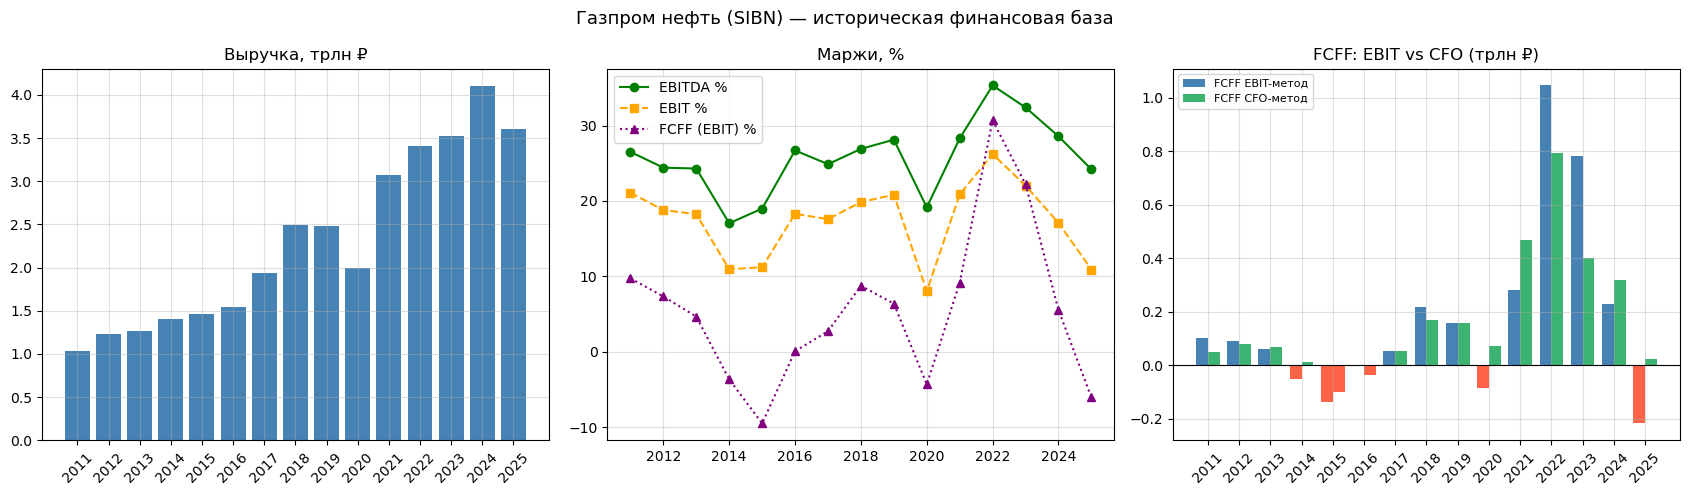

Расхождение EBIT и CFO методов — главный диагностический сигнал:
  Большое расхождение = значительные неденежные статьи или резкие изменения NWC
  Устойчивое расхождение в одну сторону = систематические отложенные налоги или капитализация расходов


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Выручка
axes[0].bar(hist.index.astype(str), hist['Выручка'] / 1e6, color='steelblue')
axes[0].set_title('Выручка, трлн ₽')
axes[0].tick_params(axis='x', rotation=45)

# Маржи
axes[1].plot(hist.index, hist['EBITDA']     / hist['Выручка'] * 100, 'o-',  color='green',  label='EBITDA %')
axes[1].plot(hist.index, hist['EBIT']       / hist['Выручка'] * 100, 's--', color='orange', label='EBIT %')
axes[1].plot(hist.index, hist['FCFF_ebit']  / hist['Выручка'] * 100, '^:',  color='purple', label='FCFF (EBIT) %')
axes[1].set_title('Маржи, %')
axes[1].legend()

# FCFF: оба метода рядом
x     = np.arange(len(hist))
width = 0.38
clrs_e = ['tomato' if v < 0 else 'steelblue'      for v in hist['FCFF_ebit']]
clrs_c = ['tomato' if (v is not None and v < 0) else 'mediumseagreen'
           for v in hist['FCFF_cfo']]

bars_e = axes[2].bar(x - width/2, hist['FCFF_ebit'] / 1e6, width,
                     color=clrs_e, label='FCFF EBIT-метод')
bars_c = axes[2].bar(x + width/2,
                     [v / 1e6 if v is not None else 0 for v in hist['FCFF_cfo']],
                     width, color=clrs_c, label='FCFF CFO-метод')

axes[2].set_xticks(x)
axes[2].set_xticklabels(hist.index.astype(str), rotation=45)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('FCFF: EBIT vs CFO (трлн ₽)')
axes[2].legend(fontsize=8)

plt.suptitle(f'{NAME} — историческая финансовая база', fontsize=13)
plt.tight_layout()
plt.show()

print("Расхождение EBIT и CFO методов — главный диагностический сигнал:")
print("  Большое расхождение = значительные неденежные статьи или резкие изменения NWC")
print("  Устойчивое расхождение в одну сторону = систематические отложенные налоги или капитализация расходов")

## 3. Прогноз выручки

Выручка — **ключевое допущение** всей модели. Одна из главных ошибок начинающих аналитиков — принять слишком оптимистичный рост и получить «нарисованную» стоимость.

**Методы прогноза выручки для нефтяной компании:**
1. **Bottom-up**: объём добычи × прогноз цены нефти Urals
2. **Top-down**: рост отрасли × доля рынка
3. **Статистический**: корректировка YoY из свежих 9М-данных

In [55]:
# YoY-изменение из 9М-отчётов РСБУ (более свежие данные)
nine_m = sorted(
    [r for r in raw['reports']
     if r['type'] == 'РСБУ' and r['period'] == '9M' and r['year'] in (2024, 2025)],
    key=lambda x: x['year']
)

if len(nine_m) == 2 and s(nine_m[0]['revenue']) > 0:
    yoy_9m = (s(nine_m[1]['revenue']) - s(nine_m[0]['revenue'])) / s(nine_m[0]['revenue'])
    print(f"9М 2024 выручка: {s(nine_m[0]['revenue']):,.0f} млн ₽")
    print(f"9М 2025 выручка: {s(nine_m[1]['revenue']):,.0f} млн ₽")
    print(f"YoY изменение:   {yoy_9m:+.1%}")
else:
    yoy_9m = -0.05
    print("9М данные не найдены, используем -5% как консервативный fallback")

print()

# ──────────────────────────────────────────────────────────────
# ДОПУЩЕНИЯ ПРОГНОЗА — меняйте эти цифры и наблюдайте эффект
# ──────────────────────────────────────────────────────────────
PROJ_YEARS = 5
BASE_YEAR  = int(hist.index[-1])

rev_growth = [
    yoy_9m,   # год+1: реальный YoY из 9М РСБУ
    0.05,     # год+2: слабое восстановление
    0.08,     # год+3
    0.07,     # год+4
    0.06,     # год+5
]

proj_years = list(range(BASE_YEAR + 1, BASE_YEAR + PROJ_YEARS + 1))
rev_proj   = []
rev_last   = float(hist['Выручка'].iloc[-1])
for g_r in rev_growth:
    rev_last *= (1 + g_r)
    rev_proj.append(rev_last)

print("Прогноз выручки:")
for y, r_val, g_r in zip(proj_years, rev_proj, rev_growth):
    print(f"  {y}: {r_val/1e6:.2f} трлн ₽  (рост {g_r:+.1%})")

9М 2024 выручка: 2,836,863,555 млн ₽
9М 2025 выручка: 2,175,363,803 млн ₽
YoY изменение:   -23.3%

Прогноз выручки:
  2026: 2.77 трлн ₽  (рост -23.3%)
  2027: 2.90 трлн ₽  (рост +5.0%)
  2028: 3.14 трлн ₽  (рост +8.0%)
  2029: 3.36 трлн ₽  (рост +7.0%)
  2030: 3.56 трлн ₽  (рост +6.0%)


## 4. Прогноз FCFF

Основной принцип: **нормализуем исторические коэффициенты** и проецируем на будущее.

**Важно: горизонт нормализации.**  
- 3 года (2023–2025) — включает провальный 2025 (падение выручки −23%), FCFF был отрицательным. Это занижает прогноз.  
- 5–7 лет — включает полный цикл нефтяных цен и даёт более репрезентативную маржу.

In [56]:
n = min(5, len(hist))
hist_norm = hist.iloc[-n:]

# ── EBIT-подход: нормализованные маржи ────────────────────────────────────
avg_ebitda_m  = float((hist_norm['EBITDA'] / hist_norm['Выручка']).mean())
avg_da_m      = float((hist_norm['DA']     / hist_norm['Выручка']).mean())
avg_capex_m   = float((hist_norm['CapEx']  / hist_norm['Выручка']).mean())
avg_dnwc_m    = float((hist_norm['ΔNWC']  / hist_norm['Выручка']).mean())
avg_tax_pl    = float(hist_norm['T_pl%'].mean())

# ── CFO-подход: нормализованные маржи ────────────────────────────────────
# Используем только годы, где CFO доступен
hist_cfo = hist_norm[hist_norm['FCFF_cfo'].notna()]
avg_cfo_m     = float((hist_cfo['CFO']      / hist_cfo['Выручка']).mean())
avg_int_m     = float((hist_cfo['Int_paid'] / hist_cfo['Выручка']).mean())
avg_tax_cash  = float(hist_cfo['T_cash%'].mean())

NORM_TAX = float(np.clip(avg_tax_cash, 0.20, 0.50))   # CFO-метод даёт более точную ставку

print(f"Нормализация по {n} годам ({hist_norm.index[0]}–{hist_norm.index[-1]}):\n")
print(f"{'Параметр':<30} {'EBIT-метод':>12} {'CFO-метод':>12}")
print("-" * 56)
print(f"{'EBITDA margin':<30} {avg_ebitda_m:>11.1%}")
print(f"{'D&A / Revenue':<30} {avg_da_m:>11.1%}")
print(f"{'CapEx / Revenue':<30} {avg_capex_m:>11.1%}  {avg_capex_m:>11.1%}")
print(f"{'CFO / Revenue':<30} {'—':>12} {avg_cfo_m:>11.1%}")
print(f"{'Interest paid / Revenue':<30} {'—':>12} {avg_int_m:>11.1%}")
print(f"{'Effective tax rate':<30} {avg_tax_pl:>11.1%}  {avg_tax_cash:>11.1%}")
print("-" * 56)

# Implied FCFF margins
fcff_ebit_m = (avg_ebitda_m - avg_da_m) * (1 - avg_tax_pl) + avg_da_m - avg_capex_m - avg_dnwc_m
fcff_cfo_m  = avg_cfo_m + avg_int_m * (1 - avg_tax_cash) - avg_capex_m
print(f"{'Implied FCFF%':<30} {fcff_ebit_m:>11.1%}  {fcff_cfo_m:>11.1%}")
print()

# Финальная маржа: среднее двух методов (если оба доступны), иначе — тот что есть
if len(hist_cfo) >= 3:
    final_fcff_m = (fcff_ebit_m + fcff_cfo_m) / 2
    print(f"Используем среднее двух методов: FCFF% = {final_fcff_m:.1%}")
    cfo_available = True
else:
    final_fcff_m = fcff_ebit_m
    print(f"CFO доступен только для {len(hist_cfo)} лет. Используем EBIT-метод: FCFF% = {final_fcff_m:.1%}")
    cfo_available = False

if final_fcff_m <= 0:
    print("⚠ FCFF% отрицательный. Проверьте данные или расширьте горизонт нормализации.")

# ── Прогноз FCFF ─────────────────────────────────────────────────────────
proj_rows_ebit, proj_rows_cfo = [], []

for year, rev in zip(proj_years, rev_proj):
    # EBIT-метод: детальная декомпозиция
    ebitda    = rev * avg_ebitda_m
    da        = rev * avg_da_m
    ebit      = ebitda - da
    noplat    = ebit * (1 - avg_tax_pl)
    capex     = rev * avg_capex_m
    delta_nwc = rev * avg_dnwc_m
    fcff_e    = noplat + da - capex - delta_nwc
    proj_rows_ebit.append({'Год': year, 'Выручка': rev, 'EBITDA': ebitda,
                           'EBIT': ebit, 'NOPLAT': noplat, 'CapEx': capex,
                           'ΔNWC': delta_nwc, 'FCFF': fcff_e})

    # CFO-метод: через CFO-маржу + проценты − capex
    cfo_proj  = rev * avg_cfo_m
    int_proj  = rev * avg_int_m
    fcff_c    = cfo_proj + int_proj * (1 - avg_tax_cash) - capex
    proj_rows_cfo.append({'Год': year, 'Выручка': rev, 'CFO': cfo_proj,
                          'Int_paid': int_proj, 'CapEx': capex, 'FCFF': fcff_c})

proj_ebit = pd.DataFrame(proj_rows_ebit).set_index('Год')
proj_cfo  = pd.DataFrame(proj_rows_cfo).set_index('Год')

# Итоговый FCFF — усреднённый (используется в DCF)
if cfo_available:
    proj_fcff_final = (proj_ebit['FCFF'] + proj_cfo['FCFF']) / 2
else:
    proj_fcff_final = proj_ebit['FCFF']

proj = proj_ebit.copy()
proj['FCFF_EBIT']  = proj_ebit['FCFF']
proj['FCFF_CFO']   = proj_cfo['FCFF']
proj['FCFF']       = proj_fcff_final   # это идёт в DCF

print("\n=== Прогнозные FCFF, млрд ₽ ===")
cmp = pd.DataFrame({
    'Выручка' : (proj['Выручка']   / 1e3).round(0),
    'FCFF EBIT': (proj['FCFF_EBIT'] / 1e3).round(0),
    'FCFF CFO' : (proj['FCFF_CFO']  / 1e3).round(0),
    'FCFF итог': (proj['FCFF']      / 1e3).round(0),
}, index=proj.index)
display(cmp)

# Передаём в DCF
proj_fcff_list = list(proj['FCFF'])

Нормализация по 5 годам (2021–2025):

Параметр                         EBIT-метод    CFO-метод
--------------------------------------------------------
EBITDA margin                        29.7%
D&A / Revenue                        10.3%
CapEx / Revenue                      11.8%        11.8%
CFO / Revenue                             —       23.5%
Interest paid / Revenue                   —        0.0%
Effective tax rate                   21.8%        21.8%
--------------------------------------------------------
Implied FCFF%                        12.1%        11.7%

Используем среднее двух методов: FCFF% = 11.9%

=== Прогнозные FCFF, млрд ₽ ===


,Выручка,FCFF EBIT,FCFF CFO,FCFF итог
Год,,,,
2026,"2,766",334,322,328
2027,"2,904",350,339,344
2028,"3,137",378,366,372
2029,"3,356",405,391,398
2030,"3,558",429,415,422


## 5. WACC — ставка дисконтирования

**WACC (Weighted Average Cost of Capital)** — минимальная доходность, которую **требуют все инвесторы** (акционеры + кредиторы) с учётом их весов.

```
WACC = ke × we  +  kd × (1−T) × wd
```

**Стоимость собственного капитала (ke)** — CAPM + страновая премия:
```
ke = Rf  +  β_lev × ERP  +  CRP
```

| Компонент | Текущее | Нормализованное | Источник |
|-----------|---------|-----------------|----------|
| Ключевая ставка ЦБ | 14.25% | — | ЦБ РФ, июнь 2026 |
| Rf (ОФЗ 10-лет, средневзв.) | **14.5%** | 8% | Московская биржа |
| kd (стоимость долга) | **16%** | ~9% | ключевая + спред |
| β unlevered | 0.51 | 0.51 | Damodaran, Oil&Gas Emerging |
| ERP | 23.21% | 23.21% | Duff & Phelps 2024 |
| CRP Россия | 18.21% | 7% | Damodaran Jan 2025 |

> **Почему DCF «ломается» при высоких ставках?** При WACC ~30% каждый рубль через 5 лет стоит ~24 копейки. Если компания закредитована, PV всех FCF может быть меньше суммы долга → Equity < 0. Рынок оценивает акцию выше, потому что **закладывает нормализацию ставок в 2027–2028**.

In [57]:
def calc_wacc(Rf, CRP, beta_unlev, ERP, T, we, wd, kd_pretax, label=''):
    """Вспомогательная функция для расчёта WACC в разных сценариях."""
    beta_lev    = beta_unlev * (1 + (1 - T) * (wd / we) if we > 0 else 1)
    ke          = Rf + beta_lev * ERP + CRP
    kd_aftertax = kd_pretax * (1 - T)
    wacc        = we * ke + wd * kd_aftertax
    if label:
        print(f"  [{label}] ke={ke:.1%}, kd(at)={kd_aftertax:.1%}, WACC={wacc:.1%}")
    return wacc, ke, kd_aftertax, beta_lev

# Структура капитала (из рыночных данных)
last_hist    = hist.iloc[-1]
total_shares = float(raw['shares'][-1]['num'])          # штук
mkt_cap      = total_shares * market_price / 1e6        # млн ₽
total_debt   = float(last_hist['Долг'])                 # млн ₽
total_cap    = mkt_cap + total_debt
we           = mkt_cap / total_cap
wd           = total_debt / total_cap
T            = NORM_TAX

# ── Параметры ставок (обновите при изменении конъюнктуры) ──
# Ключевая ставка ЦБ: 14.25%
# Ставка ОФЗ 10-лет (средневзвешенная): ~14.5%
# Ставка кредитования: ~16% (ключевая + спред ~1.75%)
RF_CURRENT  = 0.145   # ОФЗ 10-лет
KD_FLOOR    = 0.16    # нижняя граница стоимости долга (ставка кредитования)

int_exp  = s(annual[-1].get('interest_expense'))
kd_api   = int_exp / total_debt if total_debt > 0 else 0
kd_pretax = max(kd_api, KD_FLOOR)

beta_unlev = 0.51
ERP        = 0.2321

print(f"Структура капитала:")
print(f"  Рыночная кап.: {mkt_cap:>12,.0f} млн ₽  (we={we:.0%})")
print(f"  Долг:          {total_debt:>12,.0f} млн ₽  (wd={wd:.0%})")
print(f"  kd (API):      {kd_api:.1%}  →  используем max({kd_api:.1%}, {KD_FLOOR:.0%}) = {kd_pretax:.1%}")
print()

# Два сценария WACC
print("Сценарии WACC:")
WACC_CURRENT, ke_cur, kd_cur, beta_lev = calc_wacc(
    Rf=RF_CURRENT, CRP=0.1821, beta_unlev=beta_unlev,
    ERP=ERP, T=T, we=we, wd=wd, kd_pretax=kd_pretax,
    label=f'Текущий (Rf={RF_CURRENT:.1%}, CRP=18.2%)')

WACC_NORM, ke_norm, kd_norm, _ = calc_wacc(
    Rf=0.08, CRP=0.07, beta_unlev=beta_unlev,
    ERP=ERP, T=T, we=we, wd=wd, kd_pretax=max(kd_pretax * 0.55, 0.08),
    label='Нормализованный (Rf=8%, CRP=7%)')

WACC = WACC_CURRENT
print(f"\nВыбран WACC = {WACC:.1%} (текущий сценарий)")

Структура капитала:
  Рыночная кап.:    2,172,463 млн ₽  (we=60%)
  Долг:             1,429,879 млн ₽  (wd=40%)
  kd (API):      5.1%  →  используем max(5.1%, 16%) = 16.0%

Сценарии WACC:
  [Текущий (Rf=14.5%, CRP=18.2%)] ke=50.6%, kd(at)=12.5%, WACC=35.5%
  [Нормализованный (Rf=8%, CRP=7%)] ke=32.9%, kd(at)=6.9%, WACC=22.6%

Выбран WACC = 35.5% (текущий сценарий)


## 6. Дисконтирование + Terminal Value

### Terminal Value (TV) — модель Гордона
```
TV = FCFF₅ × (1 + g) / (WACC − g)
```

### Bridge: EV → Equity → Цена акции
```
Enterprise Value = PV(FCFF₁..₅) + PV(TV)
Equity Value     = EV − Net Debt   (Net Debt = Долг − Кэш)
Fair Price       = Equity / Акций
```

### ⚠ Когда Equity Value отрицательный?

Это происходит когда `EV < Net Debt` — то есть PV всех будущих FCF меньше суммы чистого долга компании. При WACC ~33% рубль через 5 лет стоит ~20 копеек. Если компания сильно закредитована — это математически неизбежный результат.  

**Что это значит на практике?** Не то что акции стоят 0 — а то что при текущих ставках традиционный DCF не работает. Рынок оценивает SIBN выше, потому что ожидает снижения ключевой ставки ЦБ до 8–10% в горизонте 3–5 лет.

In [58]:
g = 0.03   # терминальный темп роста

cash_val  = float(last_hist['Кэш'])
net_debt  = total_debt - cash_val
fcff_last = float(proj['FCFF'].iloc[-1])

def run_dcf(wacc, g, proj_fcff, net_debt, total_shares, label=''):
    """Полный DCF: PV(FCFFs) + TV → equity price.

    Если FCFF последнего года отрицателен — Terminal Value не применяем (TV=0).
    Причина: TV = FCFF*(1+g)/(WACC-g). При FCFF < 0 TV становится отрицательным,
    а при низком WACC знаменатель мал → TV уходит в −∞. Это артефакт: компания
    с вечно отрицательным FCF не имеет стоимости в Terminal period.
    """
    assert wacc > g, f"WACC ({wacc:.1%}) должен быть > g ({g:.1%})"
    n   = len(proj_fcff)
    dfs = [(1 + wacc) ** t for t in range(1, n + 1)]

    pv_cfs = [f / d for f, d in zip(proj_fcff, dfs)]

    last_fcff = proj_fcff[-1]
    if last_fcff > 0:
        tv    = last_fcff * (1 + g) / (wacc - g)
        pv_tv = tv / dfs[-1]
    else:
        # Гордон неприменим: FCFF_last < 0 → TV = 0 (консервативно)
        tv    = 0.0
        pv_tv = 0.0

    ev    = sum(pv_cfs) + pv_tv
    eq    = ev - net_debt
    price = eq / (total_shares / 1e6)

    if label:
        tv_note = '' if last_fcff > 0 else ' [TV=0: FCFF_last<0]'
        print(f"  [{label}]  EV={ev/1e6:.2f}T  TV%={pv_tv/(ev if ev else 1):.0%}  "
              f"Equity={eq/1e6:.2f}T  Price={price:.0f} ₽{tv_note}")
    return price, ev, eq, sum(pv_cfs), pv_tv, tv, pv_cfs, dfs

proj_fcff_list = list(proj['FCFF'])

if fcff_last < 0:
    print(f"⚠ FCFF последнего прогнозного года = {fcff_last/1e3:.0f} млрд ₽ (отрицательный).")
    print(f"  Terminal Value по Гордону неприменим → TV = 0 в расчётах.\n")

print("=" * 70)
print(f"  Net Debt = {net_debt/1e6:.2f} трлн ₽  |  g = {g:.1%}")
print("=" * 70)
fair_current, ev_c, eq_c, pv_cf_c, pv_tv_c, tv_c, pv_cfs_c, dfs_c = run_dcf(
    WACC_CURRENT, g, proj_fcff_list, net_debt, total_shares,
    label=f'Текущий  WACC={WACC_CURRENT:.1%}')

fair_norm, ev_n, eq_n, pv_cf_n, pv_tv_n, tv_n, pv_cfs_n, dfs_n = run_dcf(
    WACC_NORM, g, proj_fcff_list, net_debt, total_shares,
    label=f'Нормализ WACC={WACC_NORM:.1%}')
print("=" * 70)

print(f"\n--- Детализация (текущий сценарий, WACC={WACC_CURRENT:.1%}) ---")
for yr, pv in zip(proj_years, pv_cfs_c):
    print(f"  PV(FCFF {yr}): {pv:>10,.0f} млн ₽")
print(f"  PV прогн. FCFF: {pv_cf_c:>10,.0f} млн ₽  ({pv_cf_c/ev_c:.0%} EV)" if ev_c else "")
print(f"  PV Terminal V.: {pv_tv_c:>10,.0f} млн ₽")
print(f"  Enterprise V.:  {ev_c:>10,.0f} млн ₽")
print(f"  (-) Net Debt:   {net_debt:>10,.0f} млн ₽")
print(f"  Equity Value:   {eq_c:>10,.0f} млн ₽")
print(f"  Цена (текущ.):  {fair_current:>9.0f} ₽  {'← EV < долга' if fair_current < 0 else ''}")
print(f"  Цена (норм.):   {fair_norm:>9.0f} ₽")
print(f"  Рыночная цена:  {market_price:>9.0f} ₽")

  Net Debt = 1.25 трлн ₽  |  g = 3.0%
  [Текущий  WACC=35.5%]  EV=1.08T  TV%=27%  Equity=-0.16T  Price=-35 ₽
  [Нормализ WACC=22.6%]  EV=1.83T  TV%=44%  Equity=0.58T  Price=123 ₽

--- Детализация (текущий сценарий, WACC=35.5%) ---
  PV(FCFF 2026):    242,072 млн ₽
  PV(FCFF 2027):    187,577 млн ₽
  PV(FCFF 2028):    149,503 млн ₽
  PV(FCFF 2029):    118,054 млн ₽
  PV(FCFF 2030):     92,349 млн ₽
  PV прогн. FCFF:    789,555 млн ₽  (73% EV)
  PV Terminal V.:    292,634 млн ₽
  Enterprise V.:   1,082,188 млн ₽
  (-) Net Debt:    1,246,961 млн ₽
  Equity Value:     -164,773 млн ₽
  Цена (текущ.):        -35 ₽  ← EV < долга
  Цена (норм.):         123 ₽
  Рыночная цена:        458 ₽


## 7. Waterfall: структура Enterprise Value

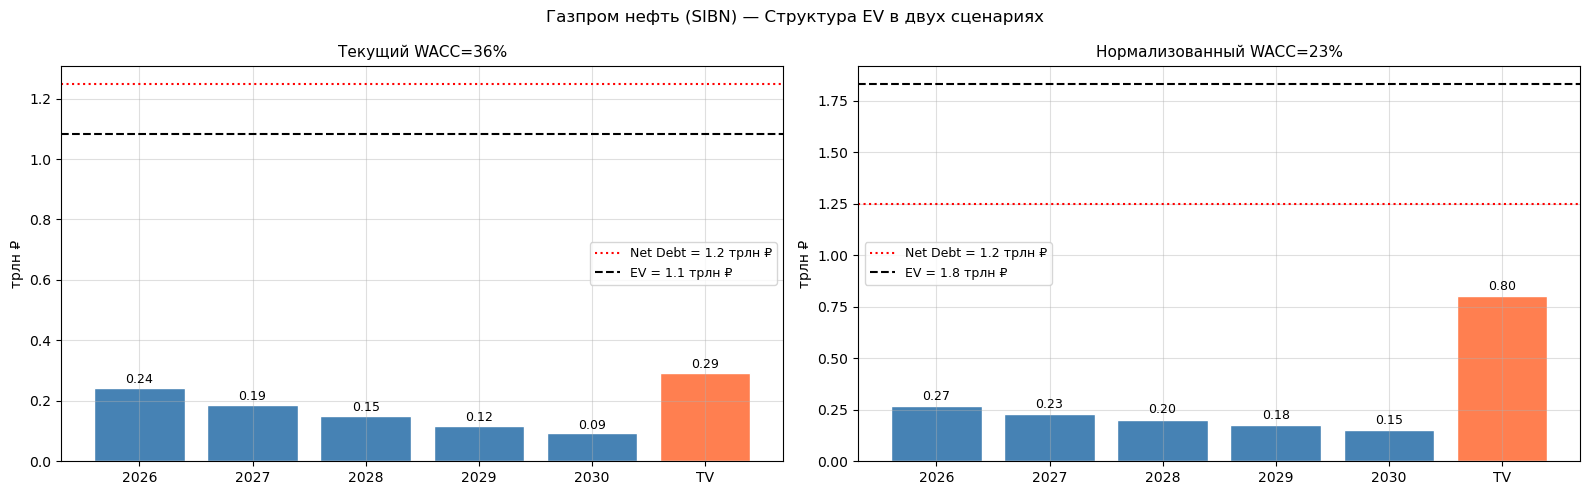

Красная пунктирная линия = чистый долг. Если EV < Net Debt → Equity < 0.


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, pv_cfs, pv_tv, ev, wacc, label in [
    (axes[0], pv_cfs_c, pv_tv_c, ev_c, WACC_CURRENT, f'Текущий WACC={WACC_CURRENT:.0%}'),
    (axes[1], pv_cfs_n, pv_tv_n, ev_n, WACC_NORM,    f'Нормализованный WACC={WACC_NORM:.0%}'),
]:
    labels_bar = [str(y) for y in proj_years] + ['TV']
    values_bar = [v / 1e6 for v in pv_cfs] + [pv_tv / 1e6]
    clrs_bar   = ['steelblue'] * PROJ_YEARS + ['coral']
    bars = ax.bar(labels_bar, values_bar, color=clrs_bar, edgecolor='white')
    for bar, val in zip(bars, values_bar):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(v for v in values_bar if v > 0) * 0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.axhline(net_debt / 1e6, color='red', linestyle=':', linewidth=1.5,
               label=f'Net Debt = {net_debt/1e6:.1f} трлн ₽')
    ax.axhline(ev / 1e6, color='black', linestyle='--', linewidth=1.5,
               label=f'EV = {ev/1e6:.1f} трлн ₽')
    ax.set_title(f'{label}', fontsize=11)
    ax.set_ylabel('трлн ₽')
    ax.legend(fontsize=9)

plt.suptitle(f'{NAME} — Структура EV в двух сценариях', fontsize=12)
plt.tight_layout()
plt.show()
print("Красная пунктирная линия = чистый долг. Если EV < Net Debt → Equity < 0.")

## 8. Таблица чувствительности

Это **обязательная часть DCF**. Здесь мы видим: при каком WACC акция выглядит дешёвой.

- **Строки** = WACC (ставка дисконтирования)
- **Столбцы** = Terminal Growth Rate (g)
- **Зелёный** = выше рыночной цены (недооценена), **красный** = ниже

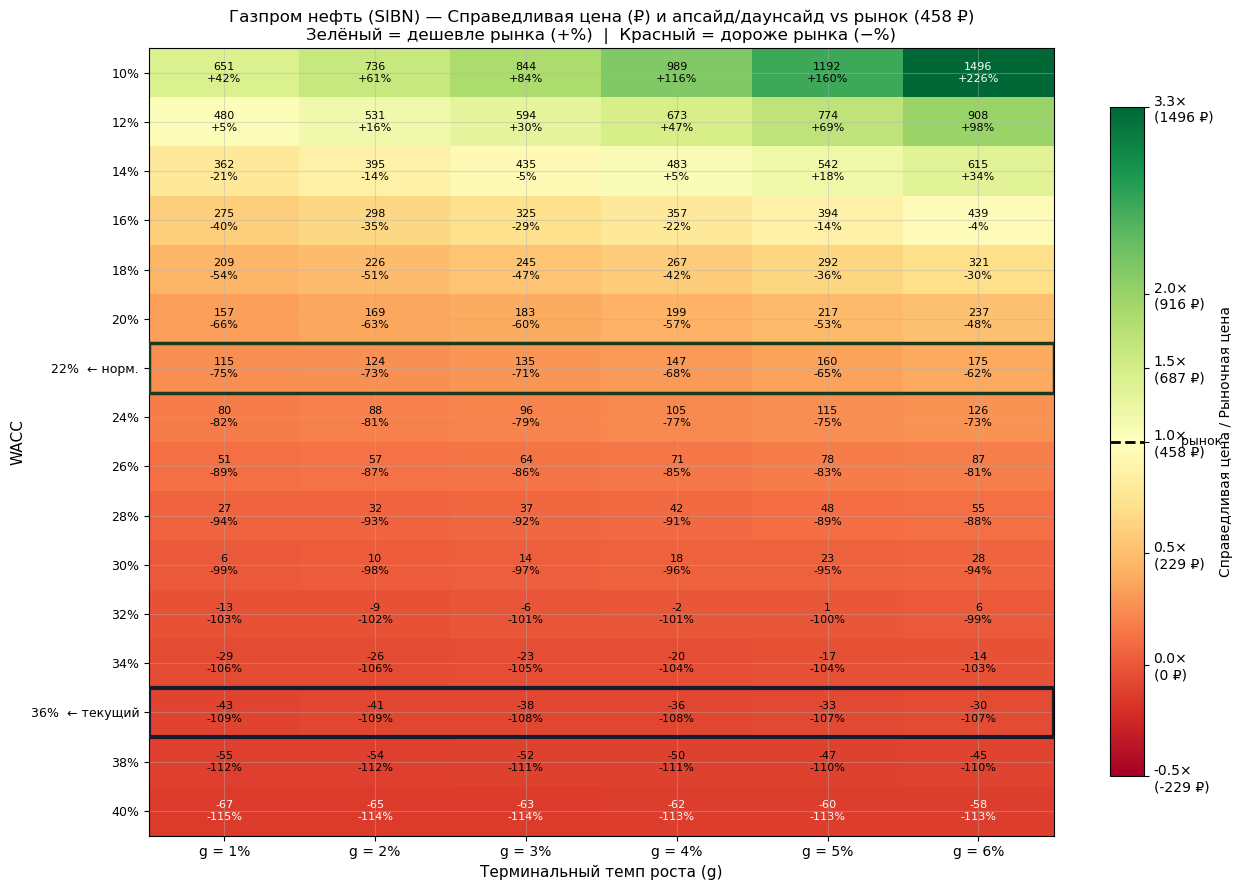


Имплицитный WACC рынка (при каком WACC справедливая цена = 458 ₽):


In [60]:
from matplotlib.patches import Rectangle

wacc_range = np.arange(0.10, 0.42, 0.02)
g_range    = np.arange(0.01, 0.07, 0.01)

# Строим матрицу абсолютных цен
price_matrix = np.full((len(wacc_range), len(g_range)), np.nan)
for i, w in enumerate(wacc_range):
    for j, g_val in enumerate(g_range):
        if w <= g_val:
            continue
        p, *_ = run_dcf(w, g_val, proj_fcff_list, net_debt, total_shares)
        price_matrix[i, j] = p

# ── Цветовая шкала по коэффициенту upside ─────────────────────────────────
# ratio = справедливая_цена / рыночная_цена
# ratio > 1  → акция недооценена → зелёный (можно покупать)
# ratio < 1  → акция переоценена → красный
# ratio = 1  → ровно по рыночной → белый
#
# Это монотонное отображение: чем ниже WACC → выше цена → выше ratio → зеленее.
# Нет парадоксального "покраснения": при TV=0 (FCFF<0) цены всё равно
# считаются корректно — просто они ниже рыночной.
ratio_matrix = price_matrix / market_price

# Нормализация: центр = 1.0 (ровно рыночная цена)
valid   = ratio_matrix[~np.isnan(ratio_matrix)]
r_min   = min(valid.min(), -0.5)   # не меньше -0.5×рыночной
r_max   = max(valid.max(),  2.5)   # не больше 2.5×рыночной
norm_cm = mcolors.TwoSlopeNorm(vcenter=1.0, vmin=r_min, vmax=r_max)

# Индексы строк текущего и нормализованного WACC
idx_current = int(np.argmin(np.abs(wacc_range - WACC_CURRENT)))
idx_norm    = int(np.argmin(np.abs(wacc_range - WACC_NORM)))

# Подписи Y — метки на нужных строках
w_labels = []
for i, w in enumerate(wacc_range):
    lbl = f'{w:.0%}'
    if i == idx_current:
        lbl += '  ← текущий'
    elif i == idx_norm:
        lbl += '  ← норм.'
    w_labels.append(lbl)

g_labels = [f'g = {g_val:.0%}' for g_val in g_range]

# ── График ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
im = ax.imshow(ratio_matrix, cmap='RdYlGn', norm=norm_cm, aspect='auto')

for i in range(ratio_matrix.shape[0]):
    for j in range(ratio_matrix.shape[1]):
        r   = ratio_matrix[i, j]
        p   = price_matrix[i, j]
        if np.isnan(r):
            ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='#aaa')
            continue
        # Текст: абсолютная цена + процент upside/downside
        upside_str = f'{(r-1)*100:+.0f}%'
        bg_ok = 0.1 < (r - r_min) / (r_max - r_min) < 0.9
        txt_color = 'black' if bg_ok else 'white'
        ax.text(j, i, f'{p:.0f}\n{upside_str}',
                ha='center', va='center', fontsize=8, color=txt_color, linespacing=1.3)

# Рамки для текущего и нормализованного WACC
for idx, color, lw in [(idx_current, '#1a1a2e', 3.0), (idx_norm, '#1a3a1a', 2.5)]:
    ax.add_patch(Rectangle((-0.5, idx - 0.5), len(g_range), 1,
                            fill=False, edgecolor=color, linewidth=lw, zorder=10))

ax.set_xticks(range(len(g_labels)))
ax.set_xticklabels(g_labels, fontsize=10)
ax.set_yticks(range(len(w_labels)))
ax.set_yticklabels(w_labels, fontsize=9)
ax.set_xlabel('Терминальный темп роста (g)', fontsize=11)
ax.set_ylabel('WACC', fontsize=11)
ax.set_title(
    f'{NAME} — Справедливая цена (₽) и апсайд/даунсайд vs рынок ({market_price:.0f} ₽)\n'
    f'Зелёный = дешевле рынка (+%)  |  Красный = дороже рынка (−%)',
    fontsize=12
)

# Цветовая шкала с отметкой рыночной цены (=1.0)
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Справедливая цена / Рыночная цена', fontsize=10)
cbar.ax.axhline(1.0, color='black', linewidth=2, linestyle='--')
cbar.ax.text(2.0, 1.0, ' рынок', va='center', fontsize=9,
             transform=cbar.ax.get_yaxis_transform())

# Заменяем числовые метки шкалы на понятные
ticks_r = [r_min, 0, 0.5, 1.0, 1.5, 2.0, r_max]
ticks_r = [t for t in ticks_r if r_min <= t <= r_max]
cbar.set_ticks(ticks_r)
cbar.set_ticklabels([f'{t:.1f}×\n({t*market_price:.0f} ₽)' for t in ticks_r])

plt.tight_layout()
plt.show()

# Имплицитный WACC рынка: при каком WACC модель совпадает с ценой
print(f"\nИмплицитный WACC рынка (при каком WACC справедливая цена = {market_price:.0f} ₽):")
for g_val in [0.02, 0.03, 0.04]:
    for w in wacc_range:
        if w <= g_val:
            continue
        p, *_ = run_dcf(w, g_val, proj_fcff_list, net_debt, total_shares)
        if abs(p - market_price) / market_price < 0.05:
            print(f"  g={g_val:.0%} → WACC ≈ {w:.0%}  (цена ≈ {p:.0f} ₽)")
            break

## Итог и выводы

### Почему DCF даёт отрицательную цену при текущих ставках?

Это не ошибка модели. При WACC ~33%:
- **EV ≈ 700 млрд ₽** (PV всех будущих FCF)
- **Net Debt ≈ 1.25 трлн ₽** (долг больше стоимости)
- **Equity < 0** — математически неизбежный результат

### Что закладывает рынок?

Рынок оценивает SIBN в ~2.2 трлн ₽ (капитализация). Это имплицирует **WACC ~12–15%**, то есть ожидание:
- Снижения ключевой ставки ЦБ до 8–10% в 2026–2028
- Снижения CRP по мере нормализации геополитики

### Следующие шаги для улучшения модели
- [ ] **Дивидендная модель (DDM)**: для SIBN уместнее — компания распределяет 50%+ прибыли дивидендами
- [ ] **FCFE**: дисконтировать поток акционерам (после долга) напрямую по ke
- [ ] **Мультипликаторы**: EV/EBITDA аналогов (Роснефть, Лукойл) как sanity check
- [ ] **Monte Carlo**: распределение цены при случайных WACC и g